 y = B0 + B1 +B2 + B3 .....
 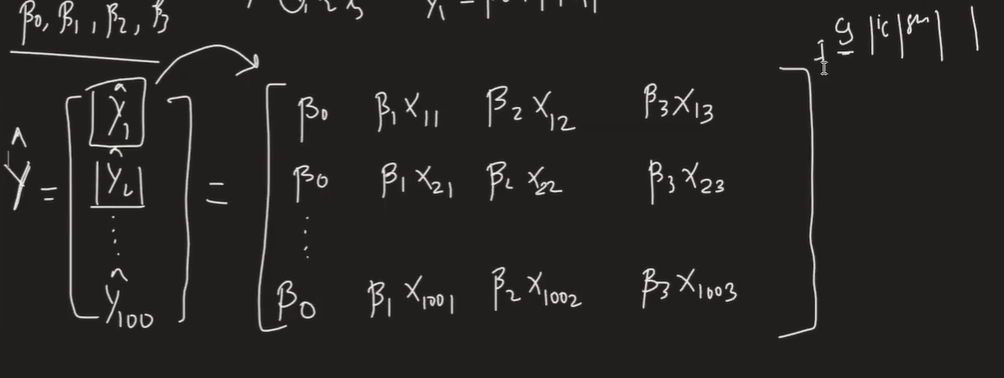


 n rows m cols 
 n*m matrix

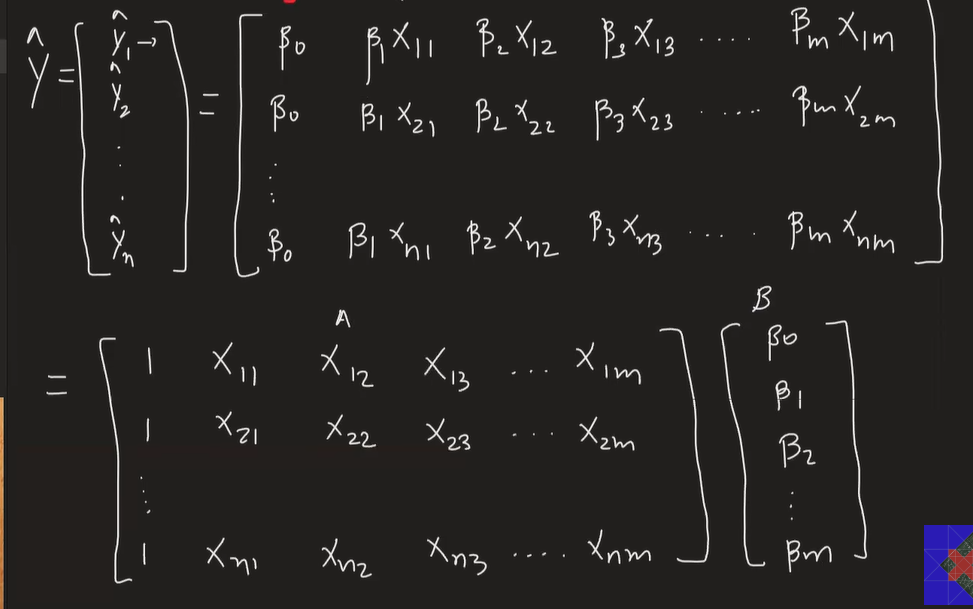

 ^
 Y = XB

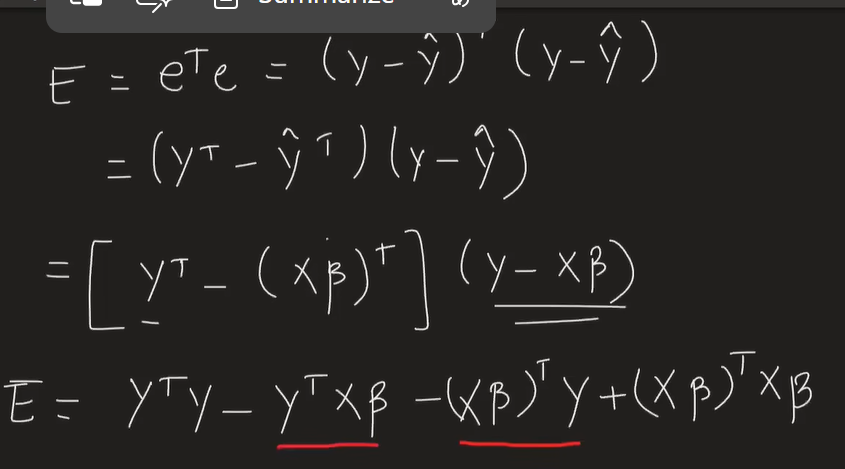

sklearn 
 -> OLS
 -> GRADIENT DESCENT


In [51]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes

In [52]:
X,y = load_diabetes(return_X_y=True)

In [53]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]], shape=(442, 10))

In [54]:
X.shape

(442, 10)

In [55]:
y.shape

(442,)

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [58]:
print(X_train.shape)
print(X_test.shape)

(353, 10)
(89, 10)


In [59]:
from sklearn.linear_model import LinearRegression

In [60]:
reg = LinearRegression()

In [61]:
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
y_pred = reg.predict(X_test)
reg.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [63]:
from sklearn.metrics import r2_score

In [64]:
r2_score(y_test,y_pred)

0.439933866156897

## Writing Multiple linear regression from scratch

In [83]:
class lr:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self,X_train,y_train):
        X_train = np.insert(X_train,0,1,axis = 1)
        # calculate the coeff 
        betas = (np.linalg.pinv(X_train.T @ X_train)) @ X_train.T @ y_train
        # betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_=betas[0]
        self.coef_=betas[1:]
        

    def predict(self,X_test):
        y_pred = np.dot(X_test,self.coef_)+self.intercept_
        return y_pred

In [88]:
LR = lr()
LR.fit(X_train,y_train)
y_pred = LR.predict(X_test)
# import matplotlib.pyplot as plt
# plt.scatter(LR.predict(X_test),y_test)
r2_score(y_test,y_pred)

0.43993386615689645

In [89]:
LR.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])